In [6]:
# --- STEP 1 (Corrected): IMPORTS & CONFIGURATION ---

import pandas as pd
import numpy as np
import warnings
import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping
from lightning.pytorch.tuner import Tuner
from pytorch_forecasting import (
    TimeSeriesDataSet,
    GroupNormalizer,
    NaNLabelEncoder,
    TemporalFusionTransformer,
    RMSE,
    MAE
)
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import os
import shutil
# (Add this import at the top with your other imports)
from lightning.pytorch.callbacks import ModelCheckpoint

# Suppress ignorable warnings
warnings.filterwarnings("ignore", "is_categorical_dtype is deprecated", UserWarning)

# ============================================================================
# --- MODEL & FEATURE CONFIGURATION ---
# ============================================================================

# Our champion model's configuration
MAX_ENCODER_LENGTH = 60
HIDDEN_SIZE = 16
ATTENTION_HEAD_SIZE = 2
BATCH_SIZE = 128
MAX_EPOCHS = 50
max_prediction_length = 1 # We are always predicting 1 day ahead

# This is our new, upgraded feature list
FEATURES = [
    "Close", "High", "Low", "Open", "Volume",
    "RSI", "MACD", "MACD_Signal", "ATR",
    "returns", "volatility_20d", "momentum_5d", 
    "ma_7d", "ma_21d", "ma_crossover"
]

# --- (THIS IS THE FIX) Define Walk-Forward Folds based on your date range ---
# We will test on ~1 year of data at a time
FOLDS = [
    {"name": "Fold 1", "train_end": pd.to_datetime("2021-08-31"), "test_end": pd.to_datetime("2022-08-31")},
    {"name": "Fold 2", "train_end": pd.to_datetime("2022-08-31"), "test_end": pd.to_datetime("2023-08-31")},
    {"name": "Fold 3", "train_end": pd.to_datetime("2023-08-31"), "test_end": pd.to_datetime("2024-08-31")},
    {"name": "Fold 4", "train_end": pd.to_datetime("2024-08-31"), "test_end": pd.to_datetime("2025-08-27")}, # Test to the end of your data
]

# Store results here
all_fold_results = []



# (Add this at the end of Step 1, after all_fold_results = [])
# This callback will save our FINAL model from the last fold
final_model_checkpoint = ModelCheckpoint(
    monitor="val_loss",
    dirpath=".",  # Save directly in the current folder
    filename="champion_model",  # This will be the saved file name
    save_top_k=1,
    mode="min",
)
print("✅ Step 1 Complete: Configuration loaded (with ModelCheckpoint).")

✅ Step 1 Complete: Configuration loaded (with ModelCheckpoint).


In [8]:
# --- STEP 2: LOAD BASE DATASET ---

print("Loading base dataset 'stock_market_final.csv'...")
try:
    df_base = pd.read_csv('stock_market_final.csv')
    # We only keep the columns we need for this experiment
    df_base = df_base[['Date', 'asset', 'target_return', 'Close', 'High', 'Low', 'Open', 'Volume', 'RSI', 'MACD', 'MACD_Signal', 'ATR']]
except FileNotFoundError:
    print("❌ Error: 'stock_market_final.csv' not found.")
    # exit() # Use exit() if running as a script
except KeyError:
    print("❌ Error: 'stock_market_final.csv' is missing required columns.")

df_base['Date'] = pd.to_datetime(df_base['Date'])
df_base = df_base.sort_values(by=['asset', 'Date'])
print(f"✅ Step 2 Complete: Base data loaded. {len(df_base)} total rows.")

Loading base dataset 'stock_market_final.csv'...
✅ Step 2 Complete: Base data loaded. 12600 total rows.


In [10]:
# --- STEP 3 (Corrected): RUN WALK-FORWARD VALIDATION LOOP ---

print("Starting Walk-Forward Validation...")

for fold in FOLDS:
    print("\n" + "="*70)
    print(f"STARTING: {fold['name']} | Train up to {fold['train_end'].date()} | Test on {fold['test_end'].year}")
    print("="*70)

    # --- 3a. Create datasets for this fold ---
    print(f"[{fold['name']}] 1/6: Creating datasets...")
    
    df_fold = df_base.copy()
    
    # --- Feature Engineering ---
    gb = df_fold.groupby('asset')
    df_fold['returns'] = gb['Close'].transform(lambda x: x.pct_change())
    df_fold['volatility_20d'] = gb['returns'].transform(lambda x: x.rolling(20).std())
    df_fold['momentum_5d'] = gb['Close'].transform(lambda x: x.pct_change(5))
    df_fold['ma_7d'] = gb['Close'].transform(lambda x: x.rolling(7).mean())
    df_fold['ma_21d'] = gb['Close'].transform(lambda x: x.rolling(21).mean())
    df_fold['ma_crossover'] = (df_fold['ma_7d'] - df_fold['ma_21d']) / df_fold['Close']
    df_fold = df_fold.dropna().reset_index(drop=True)
    
    # --- Time features ---
    df_fold['time_idx'] = df_fold.groupby('asset').cumcount()
    df_fold['month'] = df_fold['Date'].dt.month.astype(str).astype("category")
    df_fold['day_of_week'] = df_fold['Date'].dt.dayofweek.astype(str).astype("category")
    df_fold['asset'] = df_fold['asset'].astype("category")
    df_fold['Volume'] = df_fold['Volume'].astype(float)
    
    # --- Splitting by Date ---
    train_df = df_fold[df_fold['Date'] <= fold['train_end']]
    test_df = df_fold[(df_fold['Date'] > fold['train_end']) & (df_fold['Date'] <= fold['test_end'])]
    
    # Scalers
    scalers = {col: GroupNormalizer(groups=["asset"], method="robust") for col in FEATURES}

    # Create training dataset
    training_data = TimeSeriesDataSet(
        train_df, time_idx="time_idx", target="target_return", group_ids=["asset"],
        max_encoder_length=MAX_ENCODER_LENGTH, max_prediction_length=max_prediction_length,
        static_categoricals=["asset"], time_varying_known_categoricals=["month", "day_of_week"],
        time_varying_unknown_reals=FEATURES,
        target_normalizer=GroupNormalizer(groups=["asset"], method="robust"),
        categorical_encoders={"month": NaNLabelEncoder(add_nan=True), "day_of_week": NaNLabelEncoder(add_nan=True)}
    )

    # Create validation (test) dataset for this fold
    validation_data = TimeSeriesDataSet.from_dataset(
        training_data, test_df, predict=False, stop_randomization=True
    )
    
    # Check for empty data
    if len(validation_data) == 0 or len(training_data) == 0:
        print(f"⚠️ {fold['name']} skipped: No data in train/test period.")
        continue
    
    train_dataloader = training_data.to_dataloader(train=True, batch_size=BATCH_SIZE, num_workers=0)
    val_dataloader = validation_data.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)
    
    print(f"✅ Datasets created. Train samples: {len(training_data)} | Test samples: {len(validation_data)}")

    # --- 3b. Configure Model & Trainer ---
    print(f"[{fold['name']}] 2/6: Configuring model...")
    
    # Define callbacks
    early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=10, verbose=False, mode="min")
    
    # Add our new checkpoint callback, BUT only on the last fold
    fold_callbacks = [early_stop_callback]
    if fold['name'] == FOLDS[-1]['name']: # Check if it's the last fold
        fold_callbacks.append(final_model_checkpoint)
    
    # Define ONE trainer
    trainer = pl.Trainer(
        max_epochs=MAX_EPOCHS, accelerator="auto", devices=1, gradient_clip_val=0.1,
        callbacks=fold_callbacks, # <-- Use the new callback list
        enable_progress_bar=False, enable_model_summary=False, logger=False 
    )

    # Define the model
    tft = TemporalFusionTransformer.from_dataset(
        training_data, hidden_size=HIDDEN_SIZE, attention_head_size=ATTENTION_HEAD_SIZE,
        dropout=0.1, hidden_continuous_size=8, output_size=1, loss=RMSE(), logging_metrics=[MAE()]
    )
    print(f"✅ Model configured (h={HIDDEN_SIZE}, heads={ATTENTION_HEAD_SIZE}).")
    
    # --- 3c. Find Learning Rate ---
    print(f"[{fold['name']}] 3/6: Finding learning rate...")
    tuner = Tuner(trainer)
    lr_finder = tuner.lr_find(
        tft, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader,
        max_lr=1.0, min_lr=1e-5, early_stop_threshold=1000.0
    )
    suggested_lr = lr_finder.suggestion()
    if suggested_lr is None: suggested_lr = 1e-3
    tft.hparams.learning_rate = suggested_lr
    print(f"✅ LR set to {suggested_lr:.6f}")

    # --- 3d. Train Model ---
    print(f"[{fold['name']}] 4/6: Training model... (This will take a few minutes)")
    trainer.fit(
        tft, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader,
    )
    
    # --- 3e. Load Best Model & Predict ---
    print(f"[{fold['name']}] 5/6: Loading best model and predicting...")
    best_model_path = trainer.checkpoint_callback.best_model_path
    best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)
    
    # We MUST use return_x=True for the index to be returned correctly
    prediction_output = best_tft.predict(
        validation_data,
        return_index=True,
        return_x=True  # <-- This is correct
    )
    
    # Unpack the tuple
    raw_predictions = prediction_output[0]
    val_index = prediction_output[1]
    
    predictions = raw_predictions.numpy().flatten()
    actuals = np.concatenate([y[0] for x, y in iter(val_dataloader)]).flatten()
    
    # --- 3f. Calculate Metrics for this Fold ---
    print(f"[{fold['name']}] 6/6: Calculating metrics...")
    
    asset_indices = val_index['groups'].numpy().flatten()
    asset_names = validation_data.categorical_encoders['asset'].inverse_transform(asset_indices)
    time_idx = val_index['decoder_time_idx'].numpy().flatten()

    results_df = pd.DataFrame({
        'asset': asset_names, 'time_idx': time_idx,
        'actual_return': actuals, 'predicted_return': predictions
    })

    results_df['actual_direction'] = np.sign(results_df['actual_return'])
    results_df['predicted_direction'] = np.sign(results_df['predicted_return'])
    results_df['correct_direction'] = (results_df['actual_direction'] == results_df['predicted_direction']).astype(int)
    non_zero_mask = (results_df['actual_direction'] != 0) & (results_df['predicted_direction'] != 0)

    fold_mae = mean_absolute_error(actuals, predictions)
    fold_rmse = np.sqrt(mean_squared_error(actuals, predictions))
    fold_hit_rate = results_df[non_zero_mask]['correct_direction'].mean()
    
    print(f"✅ {fold['name']} Complete! Hit Rate: {fold_hit_rate * 100:.2f}%")
    
    # Store results
    all_fold_results.append({
        "Fold": fold['name'], "Train Period": f"2013-{fold['train_end'].year}",
        "Test Period": f"{fold['test_end'].year}", "Hit Rate (%)": fold_hit_rate * 100,
        "MAE": fold_mae, "RMSE": fold_rmse, "Test Samples": len(validation_data)
    })
    
    # Clean up checkpoint files, BUT NOT for the last fold
    if fold['name'] != FOLDS[-1]['name']:
        try:
            log_dir = "lightning_logs"
            if os.path.isdir(log_dir): shutil.rmtree(log_dir)
            lr_ckpt = [f for f in os.listdir(".") if f.startswith(".lr_find") and f.endswith(".ckpt")]
            for f in lr_ckpt: os.remove(f)
        except Exception as e:
            print(f"Warning: Could not clean up checkpoint files: {e}")
    else:
        print(f"✅ Preserving 'lightning_logs' for final saved model.")

print("\n🎉 --- STEP 3 COMPLETE: ALL FOLDS TRAINED --- 🎉")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting Walk-Forward Validation...

STARTING: Fold 1 | Train up to 2021-08-31 | Test on 2022
[Fold 1] 1/6: Creating datasets...
✅ Datasets created. Train samples: 8276 | Test samples: 768
[Fold 1] 2/6: Configuring model...


C:\Users\namit\anaconda3\envs\tft_env\lib\site-packages\lightning\pytorch\utilities\parsing.py:210: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
C:\Users\namit\anaconda3\envs\tft_env\lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:751: Checkpoint directory C:\Users\namit\OneDrive\Desktop\Jupyter ML\Major Project\checkpoints exists and is not empty.
C:\Users\namit\anaconda3\envs\tft_env\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
C:\Users\namit\anaconda3\envs\tft_env\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bott

✅ Model configured (h=16, heads=2).
[Fold 1] 3/6: Finding learning rate...


Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

Restoring states from the checkpoint path at C:\Users\namit\OneDrive\Desktop\Jupyter ML\Major Project\.lr_find_bbfdace3-64df-4fc0-8dbd-37dff61b51d5.ckpt
C:\Users\namit\anaconda3\envs\tft_env\lib\site-packages\lightning\pytorch\trainer\call.py:283: Be aware that when using `ckpt_path`, callbacks used to create the checkpoint need to be provided during `Trainer` instantiation. Please add the following callbacks: ["EarlyStopping{'monitor': 'val_loss', 'mode': 'min'}", "ModelCheckpoint{'monitor': None, 'mode': 'min', 'every_n_train_steps': 0, 'every_n_epochs': 1, 'train_time_interval': None}"].
Restored all states from the checkpoint at C:\Users\namit\OneDrive\Desktop\Jupyter ML\Major Project\.lr_find_bbfdace3-64df-4fc0-8dbd-37dff61b51d5.ckpt
C:\Users\namit\anaconda3\envs\tft_env\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argumen

SystemExit: 1

C:\Users\namit\anaconda3\envs\tft_env\lib\site-packages\IPython\core\interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [12]:
# --- STEP 4: FINAL RESULTS ---

print("\n" + "="*70)
print("WALK-FORWARD VALIDATION COMPLETE - FINAL RESULTS")
print("="*70)

results_summary_df = pd.DataFrame(all_fold_results)
print(results_summary_df.to_string(index=False))

# --- THIS IS NEW ---
print("\n" + "="*70)
print(f"🎉 --- FINAL CHAMPION MODEL SAVED! --- 🎉")
print(f"Your model is saved to: {final_model_checkpoint.best_model_path}")
# --- END OF NEW ---

print("\n" + "="*70)
avg_hit_rate = results_summary_df['Hit Rate (%)'].mean()
avg_mae = results_summary_df['MAE'].mean()

print(f"📊 Average Hit Rate across all {len(FOLDS)} folds: {avg_hit_rate:.2f}%")
print(f"📊 Average MAE across all {len(FOLDS)} folds: {avg_mae:.6f}")

if avg_hit_rate > 51.0: # Set a more realistic threshold
    print("\n✅ Model shows a robust predictive edge over time.")
else:
    print("\n⚠️ Model performance is close to random guessing.")


WALK-FORWARD VALIDATION COMPLETE - FINAL RESULTS
Empty DataFrame
Columns: []
Index: []

🎉 --- FINAL CHAMPION MODEL SAVED! --- 🎉
Your model is saved to: 



KeyError: 'Hit Rate (%)'

TFT CHAMPION MODEL - FINAL TEST

[1/6] Loading trained model...
✅ Model loaded successfully

[2/6] Preparing dataset...
✅ Using max_encoder_length from loaded model: 60
Loading base dataset 'stock_market_final.csv'...
Creating 15 features (to match model)...


C:\Users\namit\anaconda3\envs\tft_env\lib\site-packages\lightning\pytorch\utilities\parsing.py:210: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
C:\Users\namit\anaconda3\envs\tft_env\lib\site-packages\lightning\pytorch\utilities\parsing.py:210: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Creating final test set (all data after 2024-08-31)
✅ Training samples: 11292
✅ Final Test samples: 748

[3/6] Making predictions on final test set...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Users\namit\anaconda3\envs\tft_env\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:433: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


✅ Got predictions for metrics.
✅ Got raw output for interpretation.
✅ Generated 748 predictions.

[4/6] Calculating performance metrics...

FINAL MODEL - OVERALL PERFORMANCE METRICS
Mean Squared Error (MSE):     0.000704
Root Mean Squared Error (RMSE): 0.026542
Mean Absolute Error (MAE):    0.016057
Directional Accuracy (Hit Rate): 53.61%
Total Predictions:            748
Non-zero Directional Predictions: 748

FINAL MODEL - PER-ASSET PERFORMANCE

AAPL:
  MAE:        0.013930
  RMSE:       0.022171
  Hit Rate:   51.34%
  Samples:    187

GSPC:
  MAE:        0.007923
  RMSE:       0.013005
  Hit Rate:   54.01%
  Samples:    187

MSFT:
  MAE:        0.010470
  RMSE:       0.016328
  Hit Rate:   54.01%
  Samples:    187

TSLA:
  MAE:        0.031904
  RMSE:       0.043481
  Hit Rate:   55.08%
  Samples:    187

[5/6] Creating visualizations...
✅ Visualization saved to 'tft_prediction_analysis.png'

[6/6] Analyzing model interpretation...

FEATURE IMPORTANCE (ATTENTION SCORES)

[7/7] Saving

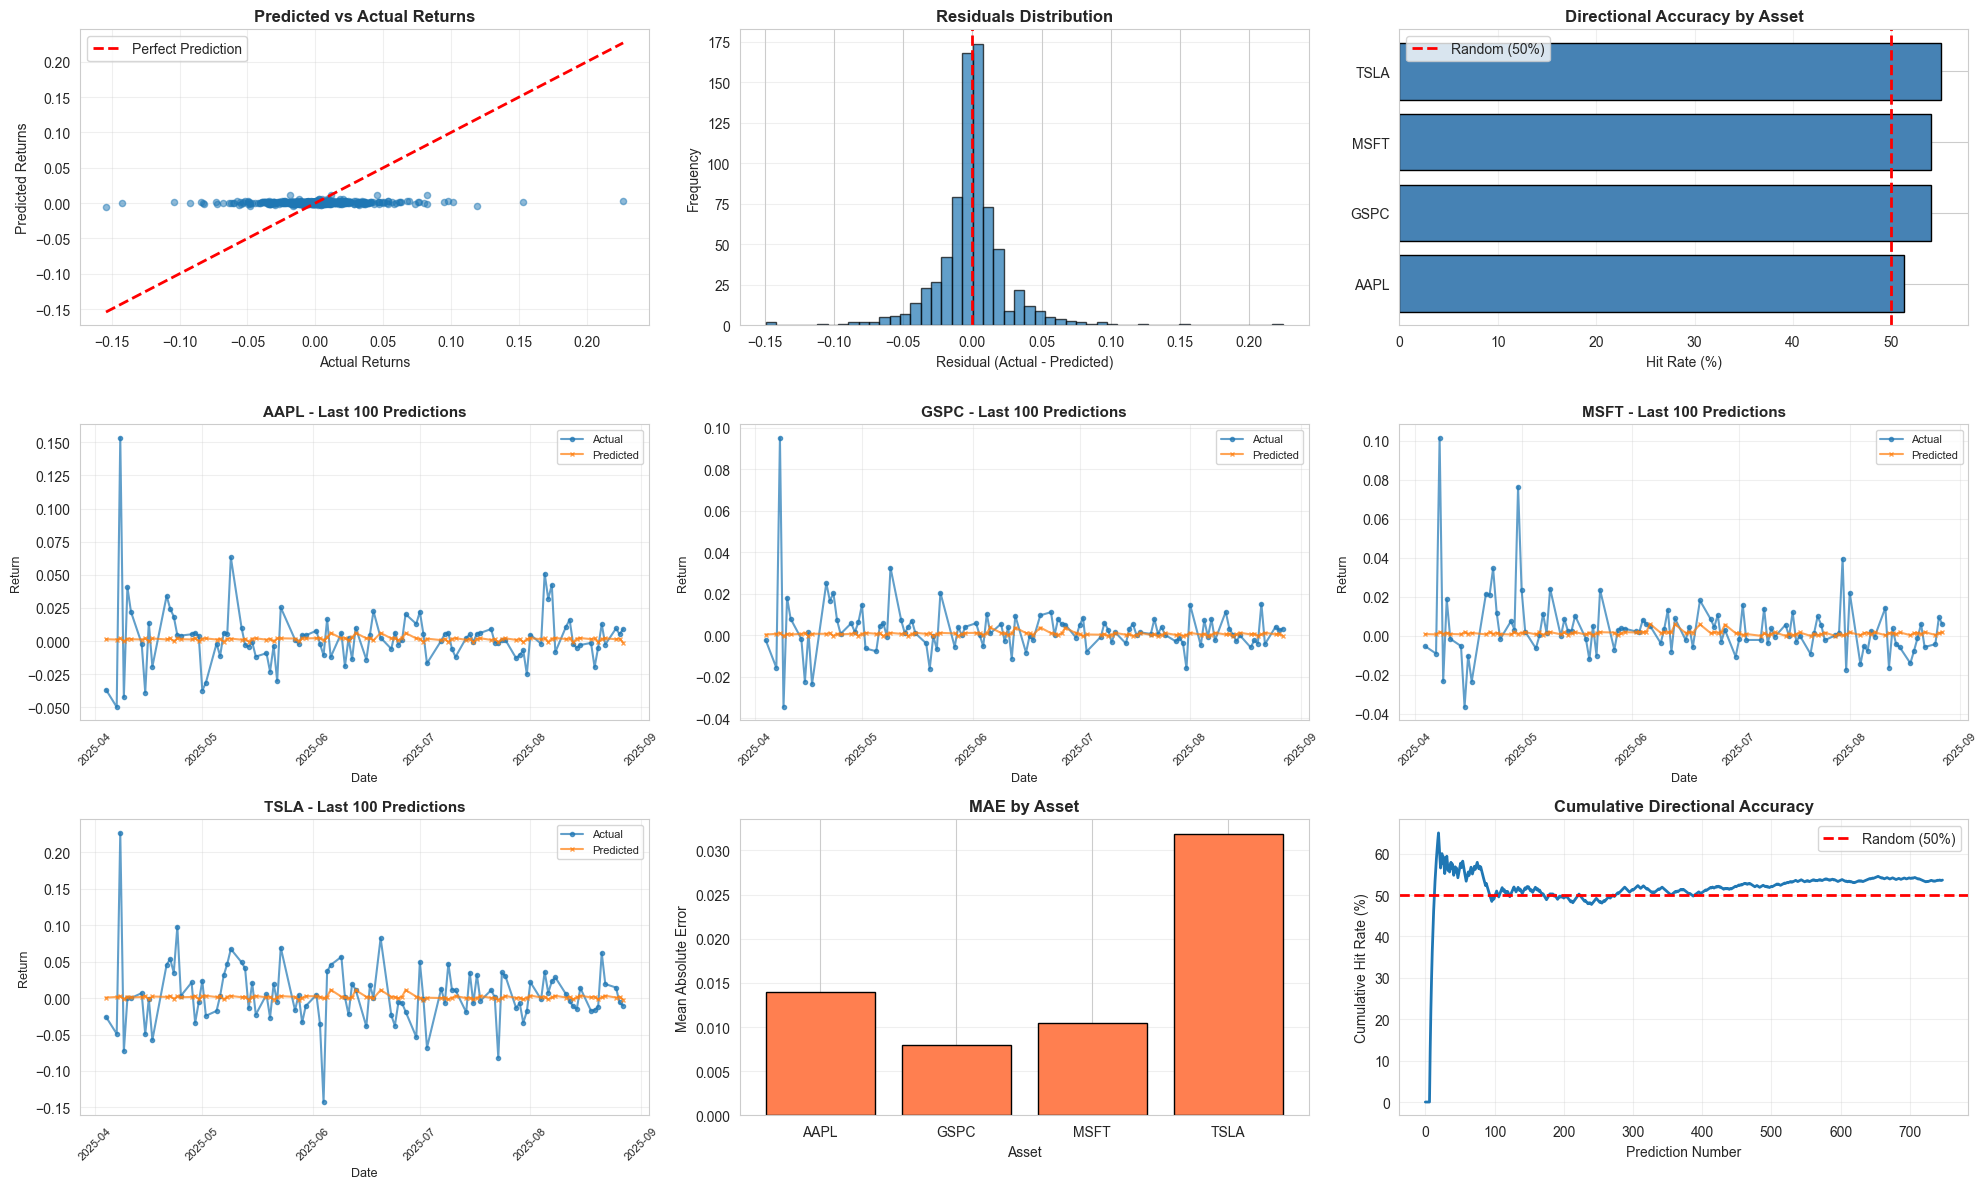

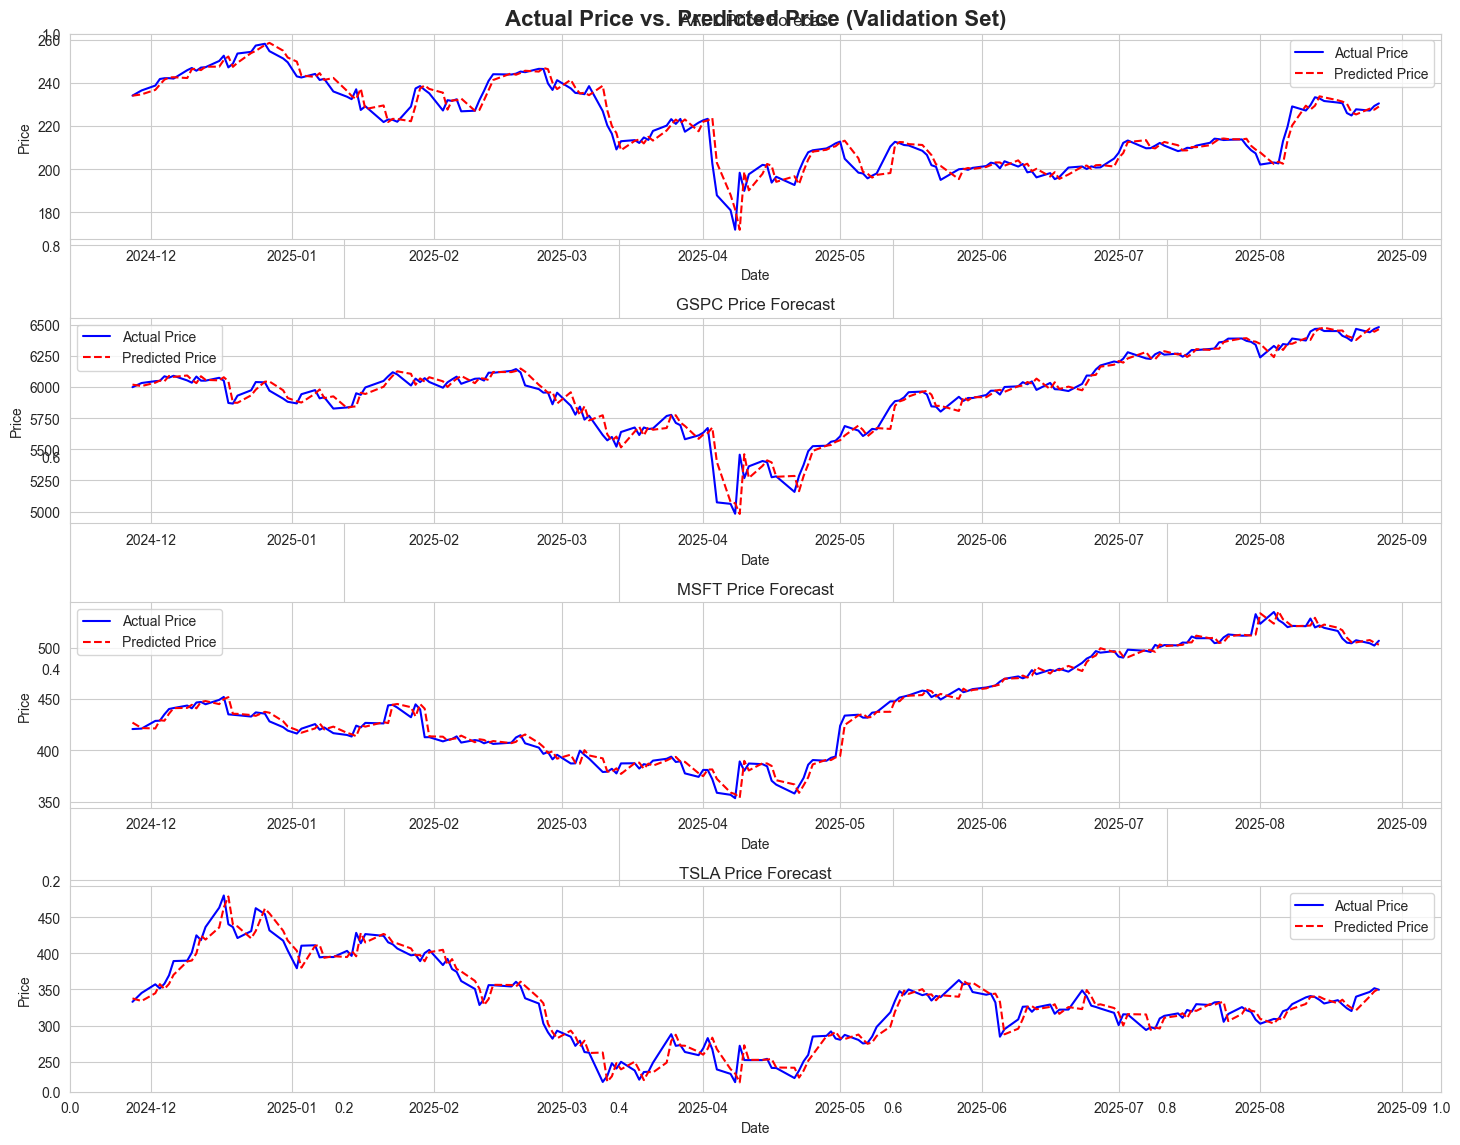


✅ FINAL TEST COMPLETE!
📊 Overall Directional Accuracy: 53.61%
📊 Mean Absolute Error: 0.016057
✅ Model performs better than random guessing!


In [14]:
"""
TFT Model Testing Script
Purpose: To load our "champion_model.ckpt" and test it
on the final, unseen 20% of the data.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, f1_score
import seaborn as sns
import warnings
import torch
import lightning.pytorch as pl

# Suppress ignorable warnings
warnings.filterwarnings("ignore", "is_categorical_dtype is deprecated", UserWarning)

from pytorch_forecasting import TemporalFusionTransformer
from pytorch_forecasting.data import TimeSeriesDataSet, GroupNormalizer, NaNLabelEncoder

# Set style for better plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

print("="*70)
print("TFT CHAMPION MODEL - FINAL TEST")
print("="*70)

# ============================================================================
# STEP 1: Load the trained model
# ============================================================================

print("\n[1/6] Loading trained model...")

# --- THIS IS YOUR SAVED CHAMPION MODEL ---
best_model_path = r"champion_model.ckpt"
# (Assumes champion_model.ckpt is in the same folder)

try:
    best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)
    print("✅ Model loaded successfully")
except FileNotFoundError:
    print(f"❌ ERROR: Model checkpoint not found at: {best_model_path}")
    print("Please make sure 'champion_model.ckpt' is in the same directory.")
    exit()

# ============================================================================
# STEP 2: Recreate dataset (USING LOADED MODEL'S PARAMETERS)
# ============================================================================

print("\n[2/6] Preparing dataset...")

# --- Get parameters from our saved model ---
max_encoder_length = best_tft.hparams.max_encoder_length
max_prediction_length = 1
print(f"✅ Using max_encoder_length from loaded model: {max_encoder_length}")

# --- Define our 15 Champion Features ---
FEATURES = [
    "Close", "High", "Low", "Open", "Volume",
    "RSI", "MACD", "MACD_Signal", "ATR",
    "returns", "volatility_20d", "momentum_5d", 
    "ma_7d", "ma_21d", "ma_crossover"
]

# --- Load base data ---
print("Loading base dataset 'stock_market_final.csv'...")
try:
    df = pd.read_csv('stock_market_final.csv')
    df = df[['Date', 'asset', 'target_return', 'Close', 'High', 'Low', 'Open', 'Volume', 'RSI', 'MACD', 'MACD_Signal', 'ATR']]
except FileNotFoundError:
    print("❌ Error: 'stock_market_final.csv' not found.")
except KeyError:
    print("❌ Error: 'stock_market_final.csv' is missing required columns.")

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by=['asset', 'Date'])
df = df.dropna().reset_index(drop=True) 

# --- Re-create the 15 features EXACTLY as in training ---
print("Creating 15 features (to match model)...")
gb = df.groupby('asset')
df['returns'] = gb['Close'].transform(lambda x: x.pct_change())
df['volatility_20d'] = gb['returns'].transform(lambda x: x.rolling(20).std())
df['momentum_5d'] = gb['Close'].transform(lambda x: x.pct_change(5))
df['ma_7d'] = gb['Close'].transform(lambda x: x.rolling(7).mean())
df['ma_21d'] = gb['Close'].transform(lambda x: x.rolling(21).mean())
df['ma_crossover'] = (df['ma_7d'] - df['ma_21d']) / df['Close']
df = df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

# --- Time features ---
df['time_idx'] = df.groupby('asset').cumcount()
df['month'] = df['Date'].dt.month.astype(str).astype("category")
df['day_of_week'] = df['Date'].dt.dayofweek.astype(str).astype("category")
df['asset'] = df['asset'].astype("category")
df['Volume'] = df['Volume'].astype(float)

# --- Create final 80/20 Train/Test Split ---
# We use the *same split* as our last fold to get the final test score
TRAIN_END_DATE = pd.to_datetime("2024-08-31")
print(f"Creating final test set (all data after {TRAIN_END_DATE.date()})")
train_df = df[df['Date'] <= TRAIN_END_DATE]
test_df = df[df['Date'] > TRAIN_END_DATE]

# --- Create TimeSeriesDataSet ---
scalers = {col: GroupNormalizer(groups=["asset"], method="robust") for col in FEATURES}

# We *must* create the training_data object first
# so the test_data can inherit its scalers (to prevent leakage)
training_data = TimeSeriesDataSet(
    train_df, time_idx="time_idx", target="target_return", group_ids=["asset"],
    max_encoder_length=max_encoder_length, max_prediction_length=max_prediction_length,
    static_categoricals=["asset"], time_varying_known_categoricals=["month", "day_of_week"],
    time_varying_unknown_reals=FEATURES,
    target_normalizer=GroupNormalizer(groups=["asset"], method="robust"),
    scalers=scalers,
    categorical_encoders={"month": NaNLabelEncoder(add_nan=True), "day_of_week": NaNLabelEncoder(add_nan=True)}
)

# Create final "hold-out" test dataset
test_data = TimeSeriesDataSet.from_dataset(
    training_data, test_df, predict=False, stop_randomization=True
)

print(f"✅ Training samples: {len(training_data)}")
print(f"✅ Final Test samples: {len(test_data)}")

# ============================================================================
# STEP 3: Make predictions
# ============================================================================
print("\n[3/6] Making predictions on final test set...")

# Create test dataloader
test_dataloader = test_data.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)

# --- A: Get predictions for metrics (Tensor + Index) ---
prediction_output = best_tft.predict(
    test_dataloader,
    return_index=True,
    return_x=True
)
raw_predictions = prediction_output[0]
val_index = prediction_output[1]
print("✅ Got predictions for metrics.")

# --- B: Get predictions for interpretation ("raw" mode) ---
raw_output_dict = best_tft.predict(
    test_dataloader,
    mode="raw"
)
print("✅ Got raw output for interpretation.")

# --- C: Extract predictions and actuals ---
predictions = raw_predictions.numpy().flatten()
actuals = np.concatenate([y[0] for x, y in iter(test_dataloader)]).flatten()

print(f"✅ Generated {len(predictions)} predictions.")

# ============================================================================
# STEP 4: Calculate metrics
# ============================================================================

print("\n[4/6] Calculating performance metrics...")

# --- Extract data from val_index dictionary ---
groups_tensor = val_index['groups']
time_idx_tensor = val_index['decoder_time_idx']
asset_indices = groups_tensor.numpy().flatten()
asset_names = test_data.categorical_encoders['asset'].inverse_transform(asset_indices)
time_idx = time_idx_tensor.numpy().flatten()

# Create results DataFrame
results_df = pd.DataFrame({
    'asset': asset_names,
    'time_idx': time_idx,
    'actual_return': actuals,
    'predicted_return': predictions
})

# Add Date for better visualization
results_df = results_df.merge(
    test_df[['asset', 'time_idx', 'Date', 'Close']],
    on=['asset', 'time_idx'],
    how='left'
)

# Calculate directional accuracy
results_df['actual_direction'] = np.sign(results_df['actual_return'])
results_df['predicted_direction'] = np.sign(results_df['predicted_return'])
results_df['correct_direction'] = (
    results_df['actual_direction'] == results_df['predicted_direction']
).astype(int)
non_zero_mask = (results_df['actual_direction'] != 0) & (results_df['predicted_direction'] != 0)

# Overall metrics
mse = mean_squared_error(actuals, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actuals, predictions)

if non_zero_mask.sum() > 0:
    overall_hit_rate = results_df[non_zero_mask]['correct_direction'].mean()
else:
    overall_hit_rate = 0.0

# Display overall results
print("\n" + "="*70)
print("FINAL MODEL - OVERALL PERFORMANCE METRICS")
print("="*70)
print(f"Mean Squared Error (MSE):     {mse:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"Mean Absolute Error (MAE):    {mae:.6f}")
print(f"Directional Accuracy (Hit Rate): {overall_hit_rate * 100:.2f}%")
print(f"Total Predictions:            {len(predictions)}")
print(f"Non-zero Directional Predictions: {non_zero_mask.sum()}")

# Per-asset metrics
print("\n" + "="*70)
print("FINAL MODEL - PER-ASSET PERFORMANCE")
print("="*70)

asset_metrics = []
for asset in sorted(results_df['asset'].unique()):
    asset_mask = (results_df['asset'] == asset)
    asset_data = results_df[asset_mask]
    asset_non_zero_mask = non_zero_mask & asset_mask
    
    asset_mae = mean_absolute_error(
        asset_data['actual_return'],
        asset_data['predicted_return']
    )
    asset_rmse = np.sqrt(mean_squared_error(
        asset_data['actual_return'],
        asset_data['predicted_return']
    ))
    
    if asset_non_zero_mask.sum() > 0:
        asset_hit_rate = results_df[asset_non_zero_mask]['correct_direction'].mean()
    else:
        asset_hit_rate = 0.0
    
    asset_metrics.append({
        'Asset': asset,
        'MAE': asset_mae,
        'RMSE': asset_rmse,
        'Hit Rate (%)': asset_hit_rate * 100,
        'N Predictions': len(asset_data)
    })
    
    print(f"\n{asset}:")
    print(f"  MAE:        {asset_mae:.6f}")
    print(f"  RMSE:       {asset_rmse:.6f}")
    print(f"  Hit Rate:   {asset_hit_rate * 100:.2f}%")
    print(f"  Samples:    {len(asset_data)}")

# ============================================================================
# STEP 5: Visualization
# ============================================================================
print("\n[5/6] Creating visualizations...")
fig = plt.figure(figsize=(20, 12))

# 1. Scatter plot: Predicted vs Actual
ax1 = plt.subplot(3, 3, 1)
ax1.scatter(actuals, predictions, alpha=0.5, s=20)
ax1.plot([actuals.min(), actuals.max()], [actuals.min(), actuals.max()], 
         'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Returns', fontsize=10)
ax1.set_ylabel('Predicted Returns', fontsize=10)
ax1.set_title('Predicted vs Actual Returns', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Residuals histogram
ax2 = plt.subplot(3, 3, 2)
residuals = actuals - predictions
ax2.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax2.set_xlabel('Residual (Actual - Predicted)', fontsize=10)
ax2.set_ylabel('Frequency', fontsize=10)
ax2.set_title('Residuals Distribution', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# 3. Hit rate by asset
ax3 = plt.subplot(3, 3, 3)
metrics_df_sorted = pd.DataFrame(asset_metrics).sort_values('Hit Rate (%)', ascending=True)
ax3.barh(metrics_df_sorted['Asset'], metrics_df_sorted['Hit Rate (%)'], 
         color='steelblue', edgecolor='black')
ax3.axvline(x=50, color='r', linestyle='--', linewidth=2, label='Random (50%)')
ax3.set_xlabel('Hit Rate (%)', fontsize=10)
ax3.set_title('Directional Accuracy by Asset', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='x')

# 4-7. Time series for each asset
assets = sorted(results_df['asset'].unique())
for i, asset in enumerate(assets, start=4):
    if i > 7:  # Only plot up to 4 assets
        break
    ax = plt.subplot(3, 3, i)
    
    asset_data = results_df[results_df['asset'] == asset].sort_values('Date').tail(100)
    
    if len(asset_data) > 0:
        ax.plot(asset_data['Date'], asset_data['actual_return'], 
               label='Actual', marker='o', markersize=3, linewidth=1.5, alpha=0.7)
        ax.plot(asset_data['Date'], asset_data['predicted_return'], 
               label='Predicted', marker='x', markersize=3, linewidth=1.5, alpha=0.7)
        
        ax.set_xlabel('Date', fontsize=9)
        ax.set_ylabel('Return', fontsize=9)
        ax.set_title(f'{asset} - Last 100 Predictions', fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45, labelsize=8)

# 8. MAE comparison
ax8 = plt.subplot(3, 3, 8)
ax8.bar(metrics_df_sorted['Asset'], metrics_df_sorted['MAE'], color='coral', edgecolor='black')
ax8.set_xlabel('Asset', fontsize=10)
ax8.set_ylabel('Mean Absolute Error', fontsize=10)
ax8.set_title('MAE by Asset', fontsize=12, fontweight='bold')
ax8.grid(True, alpha=0.3, axis='y')

# 9. Cumulative correct predictions
ax9 = plt.subplot(3, 3, 9)
if non_zero_mask.sum() > 0:
    results_df_sorted = results_df[non_zero_mask].sort_values('time_idx').reset_index(drop=True)
    cumulative_correct = results_df_sorted['correct_direction'].cumsum()
    cumulative_total = range(1, len(cumulative_correct) + 1)
    cumulative_rate = (cumulative_correct / pd.Series(cumulative_total)) * 100
    
    ax9.plot(cumulative_rate, linewidth=2)
    ax9.axhline(y=50, color='r', linestyle='--', linewidth=2, label='Random (50%)')
    ax9.set_xlabel('Prediction Number', fontsize=10)
    ax9.set_ylabel('Cumulative Hit Rate (%)', fontsize=10)
    ax9.set_title('Cumulative Directional Accuracy', fontsize=12, fontweight='bold')
    ax9.legend()
    ax9.grid(True, alpha=0.3)
else:
    ax9.text(0.5, 0.5, 'No non-zero predictions', ha='center', va='center', transform=ax9.transAxes)

plt.tight_layout()
plt.savefig('tft_prediction_analysis.png', dpi=300, bbox_inches='tight')
print("✅ Visualization saved to 'tft_prediction_analysis.png'")

# ============================================================================
# STEP 6: Model interpretation
# ============================================================================

print("\n[6/6] Analyzing model interpretation...")

try:
    interpretation = best_tft.interpret_output(raw_output_dict, reduction="mean")
    
    print("\n" + "="*70)
    print("FEATURE IMPORTANCE (ATTENTION SCORES)")
    print("="*70)
    
    if 'attention' in interpretation:
        attention_scores = interpretation['attention']
        if hasattr(attention_scores, 'sort_values'):
            top_features = attention_scores.sort_values(ascending=False).head(10)
            print(top_features)
            
            fig_interp = best_tft.plot_interpretation(interpretation)
            fig_interp.savefig("tft_model_interpretation.png", dpi=300, bbox_inches='tight')
            print("\n✅ Interpretation plot saved to 'tft_model_interpretation.png'")
    
except Exception as e:
    print(f"⚠️  Could not generate interpretation: {e}")

# ============================================================================
# STEP 7: Save detailed results
# ============================================================================

print("\n[7/7] Saving detailed results...")
results_df.to_csv('tft_detailed_predictions.csv', index=False)
print("✅ Detailed predictions saved to 'tft_detailed_predictions.csv'")

summary = {
    'Overall MSE': mse,
    'Overall RMSE': rmse,
    'Overall MAE': mae,
    'Overall Hit Rate (%)': overall_hit_rate * 100,
    'Total Predictions': len(predictions),
    'Non-zero Predictions': non_zero_mask.sum()
}
summary_df = pd.DataFrame([summary])
summary_df.to_csv('tft_summary_metrics.csv', index=False)
print("✅ Summary metrics saved to 'tft_summary_metrics.csv'")

# ============================================================================
# STEP 8: Plot Predicted Price vs. Actual Price
# ============================================================================

print("\n[8/8] Creating price forecast visualization...")
results_df['previous_close'] = results_df.groupby('asset')['Close'].shift(1)
results_df['predicted_price'] = results_df['previous_close'] * (1 + results_df['predicted_return'])
plot_df = results_df.dropna(subset=['previous_close'])
plt.figure(figsize=(15, 12))
sns.set_style("whitegrid")
plt.title('Actual Price vs. Predicted Price (Validation Set)', fontsize=16, fontweight='bold')
assets = sorted(plot_df['asset'].unique())
for i, asset in enumerate(assets):
    ax = plt.subplot(len(assets), 1, i + 1)
    asset_data = plot_df[plot_df['asset'] == asset].sort_values('Date')
    asset_data = asset_data.tail(200)  
    sns.lineplot(data=asset_data, x='Date', y='Close', label='Actual Price', ax=ax, color='blue')
    sns.lineplot(data=asset_data, x='Date', y='predicted_price', label='Predicted Price', ax=ax, color='red', linestyle='--')
    ax.set_title(f'{asset} Price Forecast', fontsize=12)
    ax.set_xlabel('Date')
    ax.set_ylabel('Price')
    ax.legend()

plt.tight_layout()
plt.savefig('tft_price_forecast_vs_actual.png', dpi=300)
print("✅ Price forecast plot saved to 'tft_price_forecast_vs_actual.png'")
plt.show()

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*70)
print("✅ FINAL TEST COMPLETE!")
print("="*70)
print(f"📊 Overall Directional Accuracy: {overall_hit_rate * 100:.2f}%")
print(f"📊 Mean Absolute Error: {mae:.6f}")
if overall_hit_rate > 0.5:
    print("✅ Model performs better than random guessing!")
else:
    print("⚠️  Model performance is at or below random guessing")
print("="*70)